# FASE 1: Validasi Baseline & Signifikansi Statistik

Berdasarkan referensi (Steinert et al., 2024 dan Vabalas et al., 2019), dataset yang kecil (seperti 250 baris) memiliki risiko bias yang tinggi bila hanya dievaluasi menggunakan K-Fold Cross-Validation biasa. 

Di fase ini, kita akan:
1. Menjalankan **Nested Cross-Validation (nCV)**: memisahkan *tuning* dan *evaluasi* sehingga hasil estimasinya *unbiased*.
2. Melakukan **Permutation Test**: memvalidasi apakah performa model signifikan secara statistik atau hanya kebetulan (menghitung *p-value* ML).
3. Membandingkan metrik **MCC** (Matthews Correlation Coefficient) sebagai metrik yang paling robust untuk data kecil dan imbalanced.

In [7]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import make_scorer, matthews_corrcoef
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Setup paths
BASE_DIR = Path.cwd().parent.resolve()
DATA_PATH = str(BASE_DIR / 'data' / 'umkm_success.csv')
RESULTS_PATH = str(BASE_DIR / 'results')

# Load data (RAW)
# Catatan: Kita tidak menggunakan train_preprocessed karena pre-processing (Scaling & SMOTE)
# WAJIB dilakukan DI DALAM loop cross-validation untuk Nested CV
df = pd.read_csv(DATA_PATH)
df_dropped = df.drop(columns=['Age', 'Owner_Gender'])

X = df_dropped.drop(columns=['Success'])
y = df_dropped['Success']

print("Shape X:", X.shape)
print("Distribusi y:", y.value_counts().to_dict())

Shape X: (250, 10)
Distribusi y: {0: 188, 1: 62}


## 1. Nested Cross-Validation (nCV) vs K-Fold CV

Kita akan membuat pipeline yang meliputi: `Scaling` -> `SMOTE` -> `Model`. Pembuatan pipeline ini sangat krusial karena *resampling* dan *scaling* HARUS dilakukan **di dalam** proses Cross-Validation, bukan di luar, untuk mencegah *data leakage*.

In [8]:
# Inisialisasi model
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'SVM': SVC(random_state=42, probability=True),
    'Random Forest': RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

# Parameter grid untuk proses tuning di Inner CV
param_grids = {
    'Logistic Regression': {'classifier__C': [0.1, 1, 10]},
    'SVM': {'classifier__C': [0.1, 1, 10], 'classifier__gamma': ['scale', 'auto']},
    'Random Forest': {'classifier__n_estimators': [50, 100], 'classifier__max_depth': [None, 5, 10]},
    'XGBoost': {'classifier__n_estimators': [50, 100], 'classifier__learning_rate': [0.01, 0.1]}
}

# Menggunakan MCC (Matthews Correlation Coefficient) sesuai rekomendasi referensi [3]
mcc_scorer = make_scorer(matthews_corrcoef)

In [9]:
def evaluate_nested_vs_flat(models, param_grids, X, y):
    results = []
    
    # Outer CV (5-Fold) - Digunakan untuk mengevaluasi performa sejati
    cv_outer = RepeatedStratifiedKFold(n_splits=5, n_repeats=8, random_state=42)
    # Inner CV (5-Fold) - Digunakan KHUSUS untuk tuning hyperparameter
    cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    for name, model in models.items():
        print(f"\nMemproses Model: {name}...")
        
        # Buat Pipeline (ImbPipeline agar SMOTE hanya bekerja di train fold)
        pipeline = ImbPipeline([
            ('scaler', StandardScaler()),
            ('smote', SMOTE(random_state=42)),
            ('classifier', model)
        ])
        
        # 1. Flat CV (hanya K-Fold biasa pada model default tanpa tuning param)
        flat_scores_mcc = cross_val_score(pipeline, X, y, cv=cv_outer, scoring=mcc_scorer, n_jobs=-1)
        flat_scores_auc = cross_val_score(pipeline, X, y, cv=cv_outer, scoring='roc_auc', n_jobs=-1)
        
        # 2. Nested CV (Tuning parameter di dalam fold luar)
        search_mcc = GridSearchCV(estimator=pipeline, param_grid=param_grids[name], cv=cv_inner, scoring=mcc_scorer, n_jobs=-1)
        nested_scores_mcc = cross_val_score(search_mcc, X, y, cv=cv_outer, scoring=mcc_scorer, n_jobs=-1)
        
        search_auc = GridSearchCV(estimator=pipeline, param_grid=param_grids[name], cv=cv_inner, scoring='roc_auc', n_jobs=-1)
        nested_scores_auc = cross_val_score(search_auc, X, y, cv=cv_outer, scoring='roc_auc', n_jobs=-1)
        
        results.append({
            'Model': name,
            'Flat CV MCC': flat_scores_mcc.mean(),
            'Nested CV MCC': nested_scores_mcc.mean(),
            'Flat CV AUC': flat_scores_auc.mean(),
            'Nested CV AUC': nested_scores_auc.mean()
        })
        
        print(f"  -> Selesai! Nested MCC: {nested_scores_mcc.mean():.3f}")
        
    return pd.DataFrame(results)

df_results = evaluate_nested_vs_flat(models, param_grids, X, y)
display(df_results)


Memproses Model: Logistic Regression...
  -> Selesai! Nested MCC: 0.877

Memproses Model: SVM...
  -> Selesai! Nested MCC: 0.824

Memproses Model: Random Forest...
  -> Selesai! Nested MCC: 0.716

Memproses Model: XGBoost...
  -> Selesai! Nested MCC: 0.750


,Model,Flat CV MCC,Nested CV MCC,Flat CV AUC,Nested CV AUC
0,Logistic Regression,0.867517,0.877454,0.990352,0.992089
1,SVM,0.832666,0.823632,0.984325,0.982050
2,Random Forest,0.725672,0.715861,0.966084,0.963066
3,XGBoost,0.792337,0.750411,0.976436,0.967545


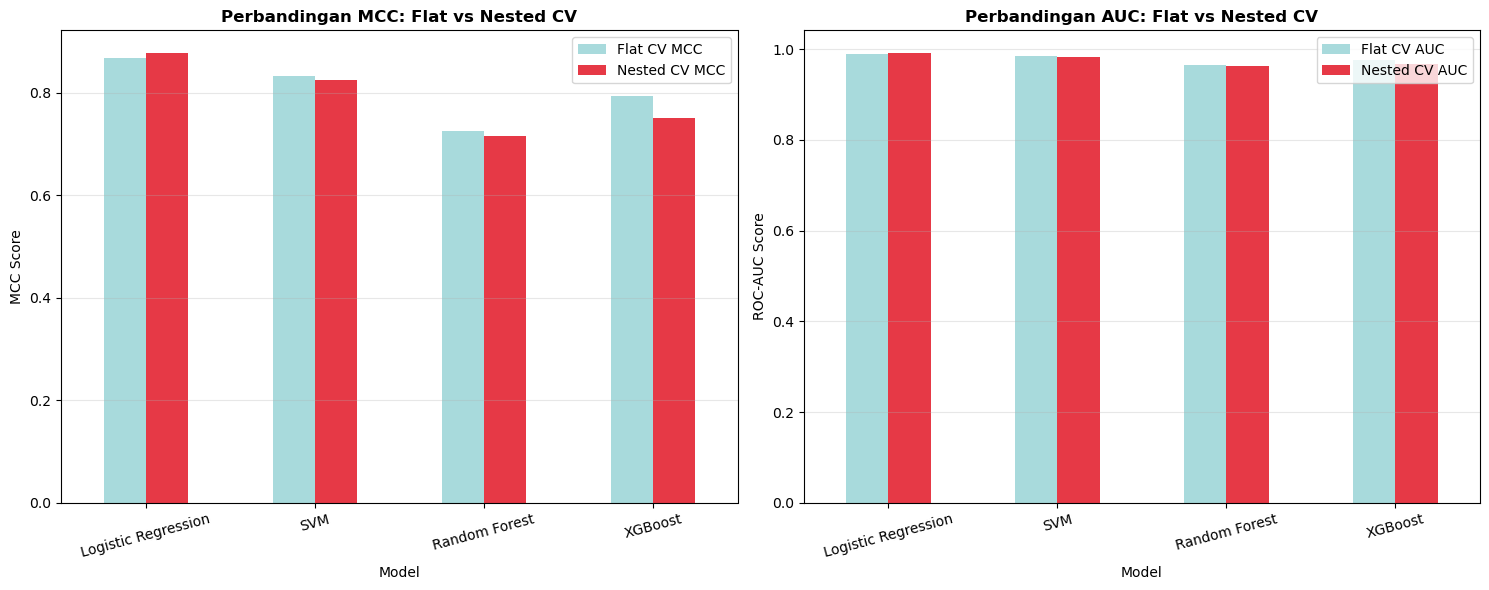

In [10]:
# Visualisasi perbandingan Flat vs Nested CV
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

df_plot_mcc = df_results[['Model', 'Flat CV MCC', 'Nested CV MCC']].set_index('Model')
df_plot_mcc.plot(kind='bar', ax=axes[0], color=['#a8dadc', '#e63946'])
axes[0].set_title('Perbandingan MCC: Flat vs Nested CV', fontweight='bold')
axes[0].set_ylabel('MCC Score')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', alpha=0.3)

df_plot_auc = df_results[['Model', 'Flat CV AUC', 'Nested CV AUC']].set_index('Model')
df_plot_auc.plot(kind='bar', ax=axes[1], color=['#a8dadc', '#e63946'])
axes[1].set_title('Perbandingan AUC: Flat vs Nested CV', fontweight='bold')
axes[1].set_ylabel('ROC-AUC Score')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_PATH}/nested_vs_flat_cv.png', dpi=300, bbox_inches='tight')
plt.show()

## 2. Permutation Test (Uji Signifikansi Statistik)

Permutation test mengacak label target $y$ berulang kali dan mengevaluasi model pada data acak tersebut. Tujuannya adalah menghitung seberapa sering model mendapatkan skor (misal MCC) yang sama atau lebih tinggi secara *kebetulan*. 

Semakin kecil probabilitas (p-value)-nya, semakin model ini terbukti tidak sekadar belajar *noise* acak.

In [11]:
from sklearn.model_selection import permutation_test_score

# Pilih model terbaik berdasarkan Nested CV MCC
best_model_name = df_results.sort_values('Nested CV MCC', ascending=False).iloc[0]['Model']
print(f"Melakukan permutation test untuk model terbaik: {best_model_name}")

pipeline_best = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('classifier', models[best_model_name])
])

cv_perm = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=42)
n_permutations = 100 # Idealnya 999 untuk paper, tapi 100 cukup untuk uji awal

# Melakukan Permutation Test
score, permutation_scores, pvalue = permutation_test_score(
    pipeline_best, X, y, scoring=mcc_scorer, cv=cv_perm, n_permutations=n_permutations, n_jobs=-1, random_state=42
)

print(f"\nTrue MCC Score: {score:.4f}")
print(f"Mean Permutation MCC Score: {permutation_scores.mean():.4f}")
print(f"P-value: {pvalue:.4f}")

if pvalue < 0.05:
    print("\nKESIMPULAN: P-value SIGNIFIKAN (<0.05). Performa model bukan sekadar kebetulan.")
else:
    print("\nKESIMPULAN: P-value TIDAK SIGNIFIKAN (>=0.05). Hati-hati, hasil prediksi mungkin dipengaruhi noise.")

Melakukan permutation test untuk model terbaik: Logistic Regression

True MCC Score: 0.8590
Mean Permutation MCC Score: 0.0005
P-value: 0.0099

KESIMPULAN: P-value SIGNIFIKAN (<0.05). Performa model bukan sekadar kebetulan.


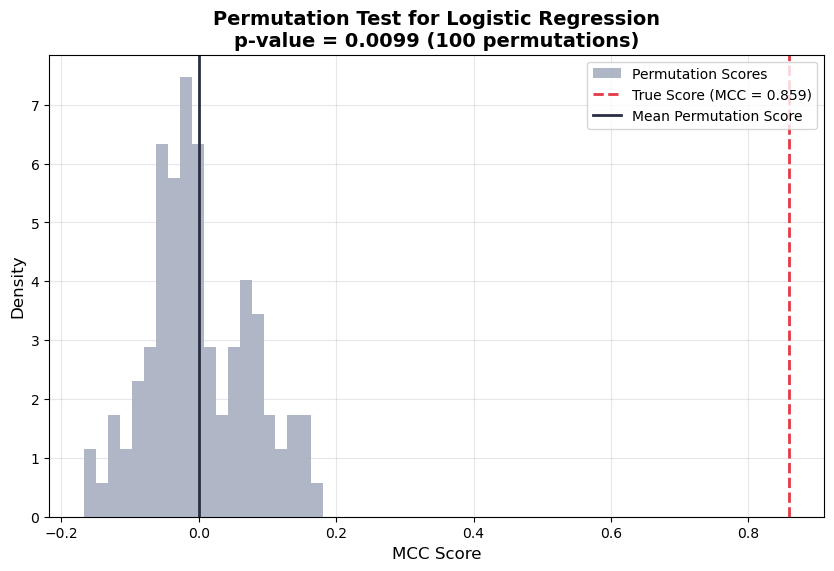

In [12]:
# Plot histogram dari permutation test
plt.figure(figsize=(10, 6))
plt.hist(permutation_scores, bins=20, density=True, alpha=0.7, color='#8d99ae', label='Permutation Scores')
plt.axvline(score, color='#e63946', linestyle='--', linewidth=2, label=f'True Score (MCC = {score:.3f})')
plt.axvline(permutation_scores.mean(), color='#2b2d42', linestyle='-', linewidth=2, label='Mean Permutation Score')

plt.title(f'Permutation Test for {best_model_name}\np-value = {pvalue:.4f} ({n_permutations} permutations)', fontsize=14, fontweight='bold')
plt.xlabel('MCC Score', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.savefig(f'{RESULTS_PATH}/permutation_test_{best_model_name.replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
plt.show()